# 03.6 - Bayesian Thinking

**Phase:** 03 - Statistics & Probability

**Status:** VERIFIED

---

## 1. What Are We Solving?

**Bayesian thinking** is a framework for updating our beliefs in light of new evidence. Instead of asking 'what is the true value?', it asks 'how should my belief change given the data?'. This is the foundation of Bayesian inference, which powers many ML methods (Naive Bayes, Bayesian networks, Bayesian optimization).

## 2. Why Does This Matter?

Bayesian methods let you incorporate prior knowledge, quantify uncertainty, and update beliefs as data arrives. This is crucial for ML: understanding uncertainty in predictions, online learning, and decision-making under uncertainty.

## 3. Prerequisites

- Unit 02.5 (Probability)
- Unit 03.2 (Probability distributions)

## 4. Learning Objectives

By the end of this notebook, you should be able to:
- State and apply Bayes' theorem
- Understand priors, likelihoods, and posteriors
- Update beliefs sequentially with new evidence
- Distinguish Bayesian from frequentist thinking
- Recognize the role of priors and their sensitivity

## 5. Mental Model

**Bayes' theorem**: `P(H|E) = P(E|H) * P(H) / P(E)`

- `P(H)` = **prior**: your belief before seeing evidence
- `P(E|H)` = **likelihood**: probability of the evidence given the hypothesis
- `P(H|E)` = **posterior**: your updated belief after seeing evidence

The posterior becomes the new prior as more evidence arrives.


## 6. Bayes' Theorem

Let's start with a classic example: a medical test. A disease affects 1% of the population. The test is 99% accurate (99% true positive rate, 99% true negative rate). If you test positive, what's the probability you actually have the disease?

Most people guess 99%, but the correct answer is much lower because the disease is rare.


In [1]:
# Medical test example
prior = 0.01          # P(disease) = 1%
sensitivity = 0.99    # P(positive | disease)
specificity = 0.99    # P(negative | no disease)

# P(positive) = P(pos|disease)*P(disease) + P(pos|no disease)*P(no disease)
p_positive = sensitivity * prior + (1 - specificity) * (1 - prior)

# Bayes: P(disease | positive)
posterior = sensitivity * prior / p_positive

print(f"Prior P(disease): {prior:.0%}")
print(f"P(positive): {p_positive:.4f}")
print(f"Posterior P(disease | positive): {posterior:.1%}")
print("\nEven with a 99% accurate test, a positive result means only ~50% chance of disease,")
print("because the disease is rare and false positives are common.")


Prior P(disease): 1%
P(positive): 0.0198
Posterior P(disease | positive): 50.0%

Even with a 99% accurate test, a positive result means only ~50% chance of disease,
because the disease is rare and false positives are common.


## 7. Sequential Updating

The power of Bayes is that we can update beliefs repeatedly. Each posterior becomes the prior for the next update. Let's see how a positive test result changes with a second independent test.


In [2]:
# Sequential updating: two positive tests
prior = 0.01
sensitivity = 0.99
specificity = 0.99

for test in [1, 2, 3]:
    p_positive = sensitivity * prior + (1 - specificity) * (1 - prior)
    posterior = sensitivity * prior / p_positive
    print(f"After {test} positive test(s): P(disease) = {posterior:.1%}")
    prior = posterior  # posterior becomes the new prior

print("\nEach positive test strengthens the belief, but the first test is the most informative.")


After 1 positive test(s): P(disease) = 50.0%
After 2 positive test(s): P(disease) = 99.0%
After 3 positive test(s): P(disease) = 100.0%

Each positive test strengthens the belief, but the first test is the most informative.


## 8. Prior Sensitivity

The prior matters. A strong prior can dominate weak evidence; weak evidence barely moves a strong prior. This is both a strength (incorporating knowledge) and a risk (bias).


In [3]:
# How the prior affects the posterior
sensitivity = 0.99
specificity = 0.99

for prior in [0.001, 0.01, 0.1, 0.5]:
    p_positive = sensitivity * prior + (1 - specificity) * (1 - prior)
    posterior = sensitivity * prior / p_positive
    print(f"Prior {prior:.1%} -> Posterior {posterior:.1%}")

print("\nThe prior strongly influences the posterior, especially with limited evidence.")


Prior 0.1% -> Posterior 9.0%
Prior 1.0% -> Posterior 50.0%
Prior 10.0% -> Posterior 91.7%
Prior 50.0% -> Posterior 99.0%

The prior strongly influences the posterior, especially with limited evidence.


## 9. Bayesian vs Frequentist

- **Frequentist**: probability is the long-run frequency of events. Parameters are fixed but unknown. Uses p-values and confidence intervals.
- **Bayesian**: probability is a degree of belief. Parameters have distributions. Uses priors, posteriors, and credible intervals.

Bayesian methods naturally handle uncertainty and prior knowledge, but require choosing a prior.


## 10. A Simple Bayesian Update with a Coin

Let's model a possibly-biased coin. We start with a prior belief about the bias, then update it as we flip the coin.


Flipped 50 times, got 39 heads.
Prior: Beta(1, 1)
Posterior: Beta(40, 12)
Posterior mean (estimated bias): 0.769
True bias: 0.7


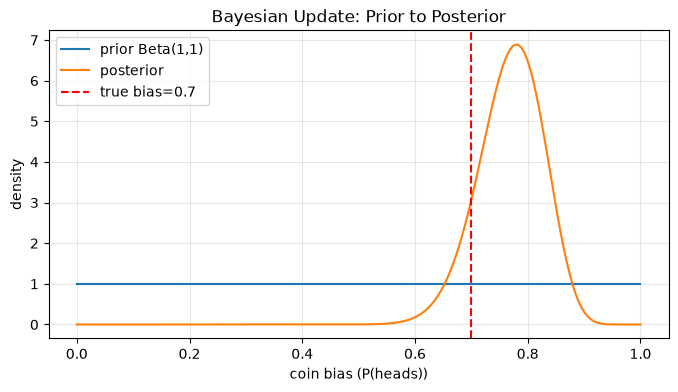

In [4]:
# Bayesian coin flipping: estimate bias of a coin
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

np.random.seed(42)

# True bias (probability of heads)
true_bias = 0.7

# Generate 50 flips
flips = np.random.binomial(1, true_bias, size=50)
n_heads = flips.sum()
n_flips = len(flips)

# Prior: uniform Beta(1,1) - no prior knowledge
a_prior, b_prior = 1, 1

# Posterior: Beta(a_prior + heads, b_prior + tails)
a_post = a_prior + n_heads
b_post = b_prior + (n_flips - n_heads)

print(f"Flipped {n_flips} times, got {n_heads} heads.")
print(f"Prior: Beta({a_prior}, {b_prior})")
print(f"Posterior: Beta({a_post}, {b_post})")
print(f"Posterior mean (estimated bias): {a_post/(a_post+b_post):.3f}")
print(f"True bias: {true_bias}")

# Plot prior and posterior
x = np.linspace(0, 1, 200)
plt.figure(figsize=(8, 4))
plt.plot(x, stats.beta.pdf(x, a_prior, b_prior), label="prior Beta(1,1)")
plt.plot(x, stats.beta.pdf(x, a_post, b_post), label="posterior")
plt.axvline(true_bias, color="red", linestyle="--", label=f"true bias={true_bias}")
plt.xlabel("coin bias (P(heads))")
plt.ylabel("density")
plt.title("Bayesian Update: Prior to Posterior")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 11. Updating with More Data

As we collect more data, the posterior concentrates around the true value and the prior matters less.


In [5]:
# More data -> posterior concentrates on true bias
true_bias = 0.7
a_prior, b_prior = 1, 1

for n in [10, 100, 1000]:
    np.random.seed(1)
    flips = np.random.binomial(1, true_bias, size=n)
    heads = flips.sum()
    a_post = a_prior + heads
    b_post = b_prior + (n - heads)
    mean = a_post / (a_post + b_post)
    # 95% credible interval
    lo, hi = stats.beta.ppf(0.025, a_post, b_post), stats.beta.ppf(0.975, a_post, b_post)
    print(f"n={n:5d}: posterior mean={mean:.3f}, 95% credible interval=[{lo:.3f}, {hi:.3f}]")

print("\nWith more data, the interval narrows and the estimate approaches the true bias (0.7).")


n=   10: posterior mean=0.833, 95% credible interval=[0.587, 0.977]
n=  100: posterior mean=0.735, 95% credible interval=[0.646, 0.816]
n= 1000: posterior mean=0.703, 95% credible interval=[0.674, 0.730]

With more data, the interval narrows and the estimate approaches the true bias (0.7).


## 12. Failure Case: Bad Prior

A strong, wrong prior can mislead you, especially with little data. This is why Bayesian methods are sensitive to prior choice.


In [6]:
# A strong wrong prior dominates with little data
true_bias = 0.7

# Strong prior centered on 0.1 (wrong!)
a_prior, b_prior = 10, 90  # mean = 0.1

np.random.seed(2)
flips = np.random.binomial(1, true_bias, size=10)
heads = flips.sum()
a_post = a_prior + heads
b_post = b_prior + (10 - heads)
mean = a_post / (a_post + b_post)

print(f"True bias: {true_bias}")
print(f"Strong wrong prior mean: 0.1")
print(f"After 10 flips, posterior mean: {mean:.3f}")
print("\nWith little data, the strong wrong prior pulls the estimate far from the truth.")
print("With enough data, the data eventually overcomes the prior.")


True bias: 0.7
Strong wrong prior mean: 0.1
After 10 flips, posterior mean: 0.182

With little data, the strong wrong prior pulls the estimate far from the truth.
With enough data, the data eventually overcomes the prior.


## 13. Debugging: Common Errors

- **Ignoring the prior**: the prior encodes knowledge; ignoring it wastes information.
- **Prior too strong**: a strong wrong prior can dominate the data.
- **Forgetting normalization**: the posterior must sum/integrate to 1.
- **Confusing posterior with likelihood**: the posterior includes the prior.

## 14. Real-World Considerations

- **Naive Bayes** classifiers use Bayes' theorem for classification.
- **Bayesian optimization** tunes hyperparameters efficiently.
- **Bayesian neural networks** quantify prediction uncertainty.
- **A/B testing** can use Bayesian methods for sequential decisions.

## 15. Common Mistakes

- Using an informative prior without justification.
- Reporting only the posterior mean, ignoring uncertainty.
- Treating the prior as fixed when it should be updated.

## 16. When NOT to Use

- Don't use Bayesian methods when you have no prior and lots of data - frequentist may be simpler.
- Don't use a strong prior when you're unsure - use a weak/uninformative prior.
- Don't ignore computational cost - full Bayesian inference can be expensive.

## 17. Challenge

A spam filter uses Bayes' theorem. 20% of emails are spam. The word 'free' appears in 60% of spam and 10% of non-spam. If an email contains 'free', what's the probability it's spam?


In [7]:
# Challenge: spam filter with Bayes
prior_spam = 0.20
p_free_given_spam = 0.60
p_free_given_not_spam = 0.10

# P(free) = P(free|spam)*P(spam) + P(free|not spam)*P(not spam)
p_free = p_free_given_spam * prior_spam + p_free_given_not_spam * (1 - prior_spam)

# P(spam | free)
posterior = p_free_given_spam * prior_spam / p_free

print(f"Prior P(spam): {prior_spam:.0%}")
print(f"P(free): {p_free:.3f}")
print(f"P(spam | contains 'free'): {posterior:.1%}")
print("\nThe word 'free' raises the spam probability from 20% to 60%.")


Prior P(spam): 20%
P(free): 0.200
P(spam | contains 'free'): 60.0%

The word 'free' raises the spam probability from 20% to 60%.


## 18. Closed-Book Recall

Without looking back:

1. Write Bayes' theorem.
2. What is a prior? A likelihood? A posterior?
3. Why is the medical test result surprising?
4. How does more data affect the posterior?
5. What is the difference between Bayesian and frequentist thinking?

## 19. Teach-Back Questions

Explain to another person:

- Why does a rare disease make a positive test less meaningful?
- How does a strong prior affect the posterior?
- Why is the posterior the new prior for the next update?

## 20. Summary

You now understand Bayesian thinking: Bayes' theorem, priors, likelihoods, and posteriors. You can update beliefs with evidence, understand prior sensitivity, and distinguish Bayesian from frequentist approaches.

## 21. Further Experiment

- Build a Naive Bayes classifier.
- Use a non-informative prior and compare to a strong prior.
- Compute a credible interval for the coin bias.

## 22. Verification Status

```
STATUS: VERIFIED
EXECUTION: PASS
DEPENDENCIES: numpy, matplotlib, scipy
OUTPUTS: PASS
LAST VERIFIED: 2026-08-28
```
